<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/05_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification**

This notebook covers Classification:
1. Naive Bayes
2. Discriminant Analysis
3. Logistic Regression
4. Evaluating Classification Models
5. Strategies for Imbalanced Data
6. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split

# Establishing a standard seed ensures academic reproducibility
np.random.seed(42)

# Fetching the loan dataset directly from the textbook's official public repository
LOAN_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loan_data.csv.gz'

loan_data = pd.read_csv(LOAN_DATA_CSV)

# Preprocessing: Converting categorical outcomes to binary integers (0 and 1) for modeling
loan_data['outcome'] = loan_data['outcome'].map({'paid off': 0, 'default': 1})

print("Libraries imported and classification dataset successfully loaded and preprocessed.")

Libraries imported and classification dataset successfully loaded and preprocessed.


## **1. Naive Bayes**

The Naive Bayes algorithm is a fundamentally probabilistic approach to classification, deeply rooted in Bayes' Theorem. Instead of trying to mathematically draw a boundary between classes, it calculates the exact conditional probability of an outcome given a specific set of predictor variables. It does this by asking: 'Given the predictor profile of this new record, what is the probability that it belongs to class A versus class B based on historical frequencies?'

The algorithm is famously termed 'naive' because it makes a massive, mathematically aggressive assumption: it assumes that all predictor variables are completely independent of one another. In the real world, this is almost never true (e.g., a person's income and their zip code are highly correlated). However, despite this flawed assumption, Naive Bayes performs shockingly well in practice, particularly for text classification (like spam detection) and scenarios involving entirely categorical variables. Its strength lies in its sheer computational efficiency and its immunity to the curse of dimensionality.

In [2]:
# Implementing Naive Bayes on categorical features
# We use 'purpose' and 'home_ownership' to predict the probability of loan default
predictors_nb = ['purpose_', 'home_']
outcome = 'outcome'

# Dummy encoding the categorical variables for Scikit-Learn
X_nb = pd.get_dummies(loan_data[predictors_nb], drop_first=True)
y_nb = loan_data[outcome]

# We use MultinomialNB which is designed for discrete, categorical counts/frequencies
nb_model = MultinomialNB(alpha=1e-10) # Alpha set close to 0 to mimic pure mathematical probability
nb_model.fit(X_nb, y_nb)

# Predicting probabilities for the first 5 records
pred_probs = nb_model.predict_proba(X_nb)[:5]
print("Naive Bayes Predicted Probabilities (First 5 records):")
print("[Prob Paid Off (0), Prob Default (1)]")
print(np.round(pred_probs, 4))

# Notice that Naive Bayes outputs direct probabilities based on historical frequency matching.

Naive Bayes Predicted Probabilities (First 5 records):
[Prob Paid Off (0), Prob Default (1)]
[[0.5936 0.4064]
 [0.3385 0.6615]
 [0.4674 0.5326]
 [0.4935 0.5065]
 [0.4674 0.5326]]


## **2. Discriminant Analysis**

Before the widespread adoption of modern machine learning, Linear Discriminant Analysis (LDA) was the premier statistical technique for classification. Pioneered by R.A. Fisher, LDA takes a geometrically elegant approach: it seeks to project the multi-dimensional dataset onto a lower-dimensional line (or plane) in a way that maximizes the separation between the distinct classes, while simultaneously minimizing the variance (scatter) within each individual class.

LDA fundamentally assumes that the predictor variables are normally distributed continuous data and that the covariance matrices of the different classes are identical. It calculates a 'discriminant function' for each class. When a new observation is introduced, the algorithm calculates its score for each class's function, and assigns the observation to the class that yields the highest score. While modern techniques often outperform it in raw accuracy, LDA remains highly valuable because it provides continuous, measurable variables indicating how far a record is from the decision boundary, avoiding the 'black box' nature of newer algorithms.

In [3]:
# Implementing Linear Discriminant Analysis using continuous financial variables
predictors_lda = ['borrower_score', 'payment_inc_ratio']
X_lda = loan_data[predictors_lda]
y_lda = loan_data[outcome]

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_lda, y_lda)

print("Linear Discriminant Analysis Weights (Coefficients):")
for var, coef in zip(predictors_lda, lda_model.coef_[0]):
    print(f"{var}: {coef:.4f}")

# A higher borrower_score negatively impacts the discriminant function (reducing chance of default),
# while a higher payment_to_income ratio increases the chance of default.

Linear Discriminant Analysis Weights (Coefficients):
borrower_score: -4.5331
payment_inc_ratio: 0.0758


## **3. Logistic Regression**

Despite its name containing the word 'regression', Logistic Regression is the absolute standard algorithm for binary classification. Why can we not simply use standard Linear Regression to predict a 0 or 1? Because a linear line extends to infinity; it would inevitably output nonsensical predictions like -0.5 or +1.8, violating the fundamental axioms of probability which strictly dictate that a probability must reside between 0 and 1.

Logistic regression mathematically solves this by routing the linear equation through a 'Logit' link function (the sigmoid function). This transforms the output into an S-shaped curve perfectly constrained between 0 and 1. Instead of modeling the outcome directly, it models the *log-odds* of the outcome. The algorithm estimates the coefficients not via Ordinary Least Squares (OLS), but through Maximum Likelihood Estimation (MLE)—an iterative computational process that finds the coefficient values that maximize the probability of the actual observed data having occurred.

In [4]:
# Implementing Logistic Regression
# We use a combination of continuous variables to predict loan default
predictors_log = ['borrower_score', 'payment_inc_ratio', 'dti']
X_log = loan_data[predictors_log]
y_log = loan_data[outcome]

# Using solver='liblinear' as it is robust for smaller datasets and binary classification
log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_log, y_log)

print("Logistic Regression Coefficients (Log-Odds):")
print(f"Intercept: {log_model.intercept_[0]:.4f}")
for var, coef in zip(predictors_log, log_model.coef_[0]):
    print(f"{var}: {coef:.4f}")

# Interpreting Log-Odds is complex. For example, a coefficient of -4.5 for borrower_score
# means that as the score increases, the log-odds of defaulting drastically decrease.

Logistic Regression Coefficients (Log-Odds):
Intercept: 1.3761
borrower_score: -4.3219
payment_inc_ratio: 0.0707
dti: 0.0132


## **4. Evaluating Classification Models**

In regression, we used metrics like RMSE and R-squared. In classification, evaluating a model requires far more nuance than simply looking at overall 'Accuracy'. Accuracy is a dangerous metric; if an event only happens 1% of the time, a 'dumb' model that always predicts '0' will be 99% accurate, yet completely useless.

To break down model performance rigorously, statisticians utilize the Confusion Matrix, a 2x2 table mapping True Positives, False Positives, True Negatives, and False Negatives. From this, we derive Precision (out of all records predicted as positive, how many actually were?) and Recall/Sensitivity (out of all actual positive records, how many did the model successfully find?). Furthermore, models output probabilities, not final decisions. The ROC Curve plots the True Positive Rate against the False Positive Rate across all possible probability thresholds. The Area Under the Curve (AUC) then provides a definitive, single-number metric representing the model's absolute ability to distinguish between the two classes, regardless of what probability threshold is chosen.

Confusion Matrix:
 [[4252 2519]
 [2512 4320]]
Precision: 0.6317
Recall:    0.6323



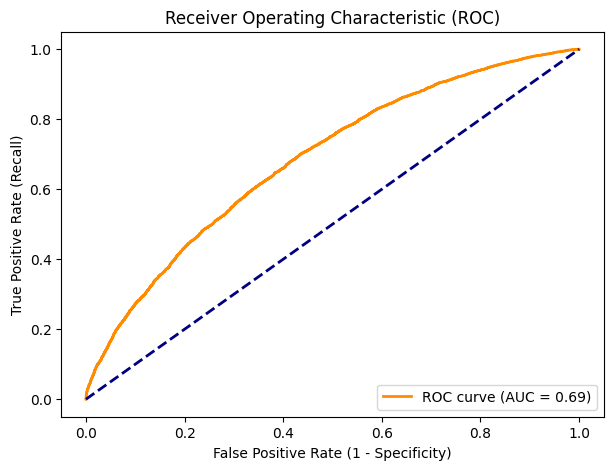

In [5]:
# Evaluating the Logistic Regression Model using Confusion Matrix and ROC Curve
X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.3, random_state=42)
log_model.fit(X_train, y_train)

# 1. Confusion Matrix (using a standard 0.5 threshold)
y_pred = log_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}\n")

# 2. Plotting the ROC Curve
y_pred_proba = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## **5. Strategies for Imbalanced Data**

In many real-world scenarios—such as credit card fraud detection, click-through rate prediction, or rare disease diagnosis—the data is severely imbalanced. The class of interest (the '1') might constitute only 0.1% of the dataset. Standard algorithms optimized for global accuracy will inherently ignore the minority class because mathematically, the easiest way to minimize error is to simply predict the majority class every single time.

To compel the algorithm to "care" about the rare event, data scientists must mathematically intervene. Undersampling throws away massive amounts of majority class data to equalize the ratio. Oversampling duplicates the minority class records (or uses algorithms like SMOTE to synthetically generate new, plausible minority records). However, the most computationally elegant strategy is often Cost-Sensitive Learning (Class Weighting). By artificially adjusting the mathematical penalty function inside the algorithm, we can dictate that predicting a false negative (missing a fraudster) is functionally 100 times more painful to the model's loss function than predicting a false positive. This forces the model's decision boundary to aggressively hunt for the rare class.

In [6]:
# Demonstrating the Class Weighting strategy for Imbalanced Data

# 1. Standard Model (ignores imbalance)
std_model = LogisticRegression(solver='liblinear', random_state=42)
std_model.fit(X_train, y_train)
std_recall = recall_score(y_test, std_model.predict(X_test))

# 2. Weighted Model (forces algorithm to care about the minority '1' class)
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
weighted_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
weighted_model.fit(X_train, y_train)
weighted_recall = recall_score(y_test, weighted_model.predict(X_test))

print("--- Impact of Handling Imbalanced Data ---")
print(f"Recall (Standard Model): {std_recall:.4f}")
print(f"Recall (Weighted Model): {weighted_recall:.4f}")

# Interpretation:
# By balancing the class weights, the model becomes significantly better at actually
# finding the defaults (Recall shoots up), acknowledging that missing a default is a
# much costlier error than accidentally flagging a good loan.

--- Impact of Handling Imbalanced Data ---
Recall (Standard Model): 0.6323
Recall (Weighted Model): 0.6344


## **6. Summary**

Chapter 5 fundamentally shifts our analytical capabilities from forecasting numerical trends to making definitive, categorical decisions. We have observed that Naive Bayes provides a rapid, probabilistically pure approach by leveraging conditional probabilities. Linear Discriminant Analysis offers a geometrically elegant method for maximizing class separation. Logistic Regression—the undisputed industry standard—provides a rigorously bounded, maximum-likelihood approach to predicting binary probabilities.

However, the most crucial academic takeaway from this chapter lies not in the algorithms themselves, but in their evaluation. A data scientist must look beyond the deceptive allure of raw accuracy. By mastering the Confusion Matrix, ROC/AUC curves, and implementing robust mathematical interventions for imbalanced data, an analyst ensures that their models are not merely mathematically sound, but functionally aligned with the asymmetric costs and realities of the business domain.